Accuracy: 0.9909194097616345

Classification Report:
               precision    recall  f1-score   support

       Movie       0.99      1.00      0.99      1227
     TV Show       1.00      0.97      0.98       535

    accuracy                           0.99      1762
   macro avg       0.99      0.99      0.99      1762
weighted avg       0.99      0.99      0.99      1762



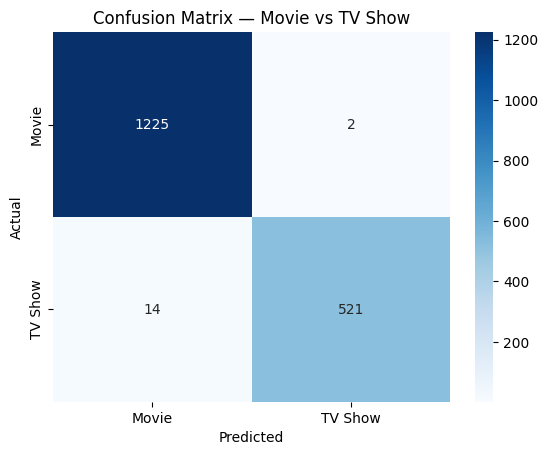

A thrilling detective series set in London. → Predicted: Movie
A romantic movie about two lovers in Paris. → Predicted: Movie
A documentary exploring deep space missions. → Predicted: Movie


In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/netflix_titles.csv")

df.drop_duplicates(inplace=True)
df.dropna(subset=['type', 'listed_in', 'description'], inplace=True)

label_encoder = LabelEncoder()
df['type_encoded'] = label_encoder.fit_transform(df['type'])

df['combined_text'] = (
    df['listed_in'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['country'].fillna('') + ' ' +
    df['release_year'].astype(str)
)

X_train, X_test, y_train, y_test = train_test_split(
    df['combined_text'], df['type_encoded'], test_size=0.2, random_state=42, stratify=df['type_encoded']
)

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=300)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix — Movie vs TV Show")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

sample_titles = [
    "A thrilling detective series set in London.",
    "A romantic movie about two lovers in Paris.",
    "A documentary exploring deep space missions."
]
sample_features = vectorizer.transform(sample_titles)
preds = model.predict(sample_features)

for text, pred in zip(sample_titles, preds):
    print(f"{text} → Predicted: {label_encoder.inverse_transform([pred])[0]}")
